## Faza 1a — EDA + decyzje preprocessingowe + split
**Zbiór:** NASA Nearest Earth Objects  
**Zadanie:** Klasyfikacja binarna — czy obiekt kosmiczny stanowi zagrożenie dla Ziemi (`hazardous`: True/False)  
**Osoba A:** EDA, decyzje preprocessingowe, podział danych

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

df = pd.read_csv('neo.csv')
print(f'Wczytano: {df.shape[0]} wierszy, {df.shape[1]} kolumn')

Wczytano: 90836 wierszy, 10 kolumn


## 1. Inspekcja surowych danych
Sprawdzamy kształt zbioru, typy kolumn i czy są braki.

In [42]:
print('--- Typy danych ---')
print(df.dtypes)
print()
print('--- Podgląd ---')
df.head(3)

--- Typy danych ---
id                      int64
name                   object
est_diameter_min      float64
est_diameter_max      float64
relative_velocity     float64
miss_distance         float64
orbiting_body          object
sentry_object            bool
absolute_magnitude    float64
hazardous                bool
dtype: object

--- Podgląd ---


,id,name,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,orbiting_body,sentry_object,absolute_magnitude,hazardous
0,2162635,162635 (2000 SS164),1.198271,2.679415,13569.249224,5.483974e+07,Earth,False,16.73,False
1,2277475,277475 (2005 WK4),0.265800,0.594347,73588.726663,6.143813e+07,Earth,False,20.00,True
2,2512244,512244 (2015 YE18),0.722030,1.614507,114258.692129,4.979872e+07,Earth,False,17.83,False


In [43]:
print('--- Braki danych ---')
print(df.isnull().sum())
print()
print('--- Statystyki opisowe ---')

df.describe()

--- Braki danych ---
id                    0
name                  0
est_diameter_min      0
est_diameter_max      0
relative_velocity     0
miss_distance         0
orbiting_body         0
sentry_object         0
absolute_magnitude    0
hazardous             0
dtype: int64

--- Statystyki opisowe ---


,id,est_diameter_min,est_diameter_max,relative_velocity,miss_distance,absolute_magnitude
count,9.083600e+04,90836.000000,90836.000000,90836.000000,9.083600e+04,90836.000000
mean,1.438288e+07,0.127432,0.284947,48066.918918,3.706655e+07,23.527103
std,2.087202e+07,0.298511,0.667491,25293.296961,2.235204e+07,2.894086
min,2.000433e+06,0.000609,0.001362,203.346433,6.745533e+03,9.230000
25%,3.448110e+06,0.019256,0.043057,28619.020645,1.721082e+07,21.340000
50%,3.748362e+06,0.048368,0.108153,44190.117890,3.784658e+07,23.700000
75%,3.884023e+06,0.143402,0.320656,62923.604633,5.654900e+07,25.700000
max,5.427591e+07,37.892650,84.730541,236990.128088,7.479865e+07,33.200000


**Wnioski z inspekcji:**  
- Brak brakujących wartości we wszystkich 10 kolumnach, czyli SimpleImputer niepotrzebny  
- Cechy mają bardzo różne zakresy: `relative_velocity` ~10⁴, `miss_distance` ~10⁷ — skalowanie konieczne  
- `orbiting_body` i `sentry_object` to są stałe kolumny

## 2. Kolumny do usunięcia
Sprawdzamy które kolumny nie wnoszą żadnej informacji do modelu.

In [44]:
# Sprawdzam czy orbiting_body i sentry_object są stałe na całym zbiorze
print('orbiting_body unique:', df['orbiting_body'].unique())
print('sentry_object unique:', df['sentry_object'].unique())

orbiting_body unique: ['Earth']
sentry_object unique: [False]


In [45]:
# Sprawdzam czy est_diameter_min i max są identyczne informacyjnie
corr_diameters = np.corrcoef(df['est_diameter_min'], df['est_diameter_max'])[0, 1]
ratio_unique = (df['est_diameter_max'] / df['est_diameter_min']).nunique()
print(f'Korelacja min/max średnicy: {corr_diameters:.6f}')
print(f'Liczba unikalnych wartości ratio max/min: {ratio_unique}  (stały stosunek = jedna cecha)')

Korelacja min/max średnicy: 1.000000
Liczba unikalnych wartości ratio max/min: 1631  (stały stosunek = jedna cecha)


In [46]:
# Pozwalam sobie Usunąć kolumny, które nic nie dają:
# - id, name: identyfikatory, nie cechy
# - orbiting_body: jedna wartość 'Earth' w 100% wierszy
# - sentry_object: jedna wartość False w 100% wierszy
# - est_diameter_max: korelacja 1.0 z est_diameter_min

cols_to_drop = ['id', 'name', 'orbiting_body', 'sentry_object', 'est_diameter_max']
df_clean = df.drop(columns=cols_to_drop)

print('Kolumny po czyszczeniu:', df_clean.columns.tolist())
print('Shape:', df_clean.shape)

Kolumny po czyszczeniu: ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude', 'hazardous']
Shape: (90836, 5)


**Wnioski:**  
- `orbiting_body` i `sentry_object` mają zerową wariancję — model nie może się na nich niczego nauczyć  
- `est_diameter_max` jest matematyczną funkcją `est_diameter_min` (stosunek stały) wiec bez sensu zostawiać
- Zostają 4 cechy: `est_diameter_min`, `relative_velocity`, `miss_distance`, `absolute_magnitude`

## 3. Nierównowaga klas
Kluczowe dla wyboru metryki i strategii radzenia sobie z imbalanced data.

Rozkład klas:
  hazardous=False:  81996 (90.3%)
  hazardous=True:   8840 (9.7%)

Stosunek klas: 1:9


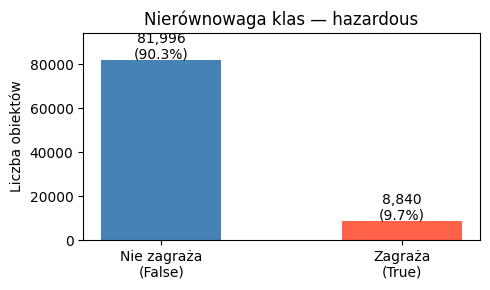

In [47]:
counts = df_clean['hazardous'].value_counts()
pcts = df_clean['hazardous'].value_counts(normalize=True) * 100

print('Rozkład klas:')
for val in [False, True]:
    print(f'  hazardous={val}: {counts[val]:6d} ({pcts[val]:.1f}%)')
print(f'\nStosunek klas: 1:{counts[False]//counts[True]:.0f}')

fig, ax = plt.subplots(figsize=(5, 3))
bars = ax.bar(['Nie zagraża\n(False)', 'Zagraża\n(True)'],
              counts.values, color=['steelblue', 'tomato'], width=0.5)
for bar, c, p in zip(bars, counts.values, pcts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 400,
            f'{c:,}\n({p:.1f}%)', ha='center', fontsize=10)
ax.set_ylabel('Liczba obiektów')
ax.set_title('Nierównowaga klas — hazardous')
ax.set_ylim(0, counts[False] * 1.15)
plt.tight_layout()
plt.show()

**Wnioski:**  
- Klasa pozytywna `hazardous=True` to tylko 9.7% zbioru — stosunek ~1:9  
- Accuracy jako metryka jest bezsensu bo model który zawsze by osiągał 90.3% accuracy nie robiąc nic w sumie
- Recall lepszy — jeden przeoczony zagrażający bedzie ważny
- Jak dla mnie powinieneś przetestować `class_weight='balanced'` vs SMOTE i porównać Recall

## 4. Rozkłady cech z podziałem na klasę
Sprawdzam czy cechy w ogóle różnią się między klasami, bo jak nie to model nic sie nie nauczy i tak

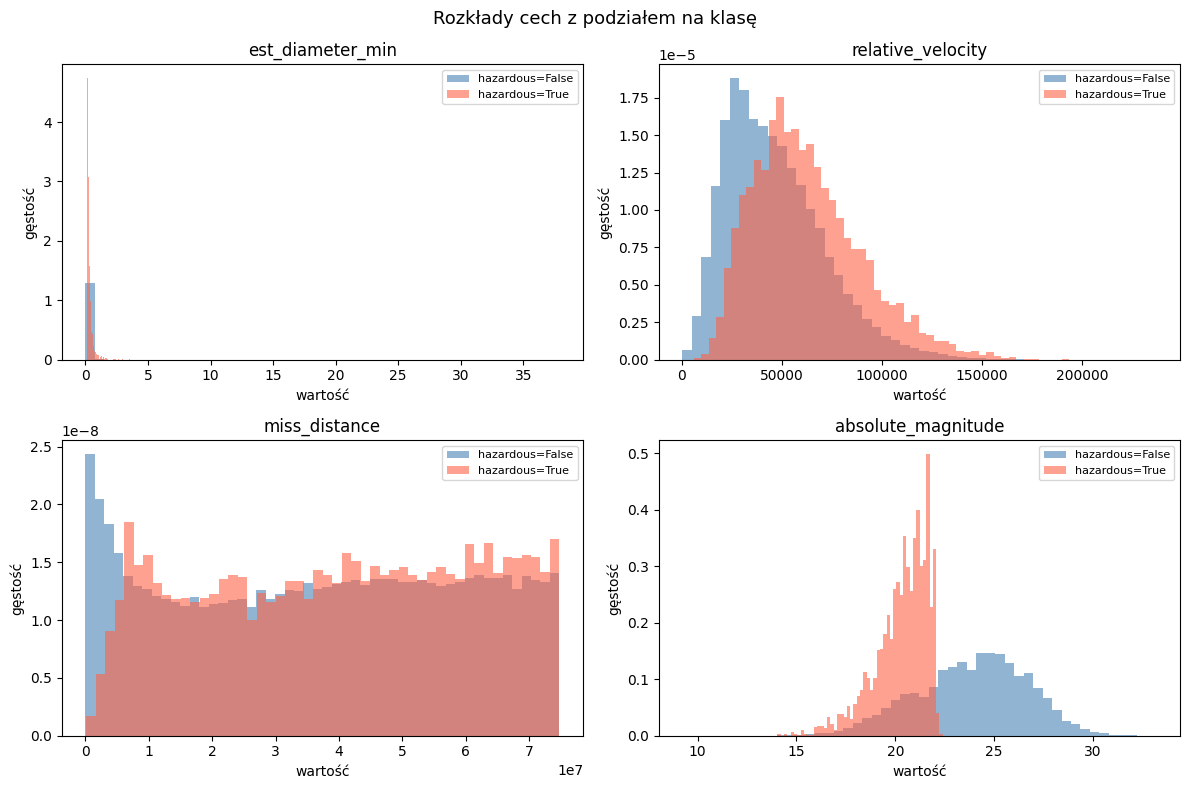

In [48]:
features = ['est_diameter_min', 'relative_velocity', 'miss_distance', 'absolute_magnitude']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(features):
    for label, color in [(False, 'steelblue'), (True, 'tomato')]:
        subset = df_clean[df_clean['hazardous'] == label][col]
        axes[i].hist(subset, bins=50, alpha=0.6, color=color,
                     label=f'hazardous={label}', density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel('wartość')
    axes[i].set_ylabel('gęstość')
    axes[i].legend(fontsize=8)

plt.suptitle('Rozkłady cech z podziałem na klasę', fontsize=13)
plt.tight_layout()
plt.show()

**Wnioski:**  
- `absolute_magnitude` — widać że niebezpieczne obiekty mają niższe wartości czyli są jaśniejsze/bliższe
- `est_diameter_min` — niebezpieczne obiekty są większe  
- `relative_velocity` — niebezpieczne obiekty mają lekko wyższą prędkość, ale rozkłady bardziej się nakładają  
- `miss_distance` — bez sensu nic nie wnosi praktycznie, znaczy jest niby że False ma peak w niższych wartościach ale ogólnie to nic nie wnoszą praiwe

## 5. Korelacje z targetem i między cechami
Sprawdzam siłę liniowej zależności każdej cechy z targetem oraz czy cechy nie są ze sobą zbyt silnie skorelowane.

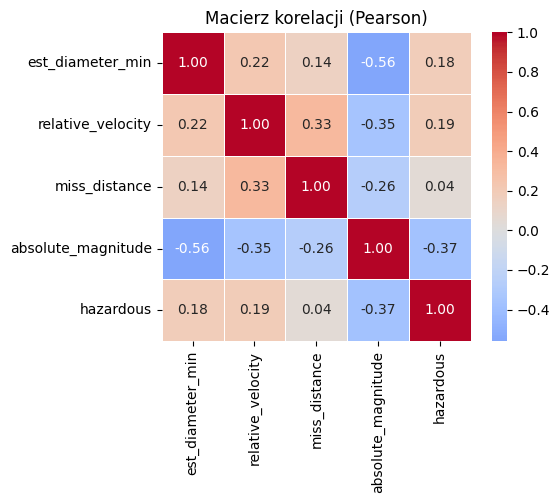

In [49]:
df_num = df_clean.copy()
df_num['hazardous'] = df_num['hazardous'].astype(int)
corr = df_num.corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Macierz korelacji (Pearson)')
plt.tight_layout()
plt.show()

**Wnioski:**  
- `absolute_magnitude` — najsilniejsza korelacja z targetem bo im mniejsza wartość, tym bardziej niebezpieczny obiekt  
- `miss_distance` — korelacja +0.04 — praktycznie zerowa, ale można zostawić bo może wnosić coś nieliniowego  
- Brak silnych korelacji między samymi cechami, wszystkie 4 cechy zostają

## 6. Outliery
Sprawdzam ile jest wartości ekstremalnych i czy powinninno się je usunąć.

Outliery metodą IQR (granica = Q1/Q3 ± 1.5×IQR):
  est_diameter_min:  8306 (9.1%)
  relative_velocity:  1574 (1.7%)
  miss_distance:     0 (0.0%)
  absolute_magnitude:   101 (0.1%)


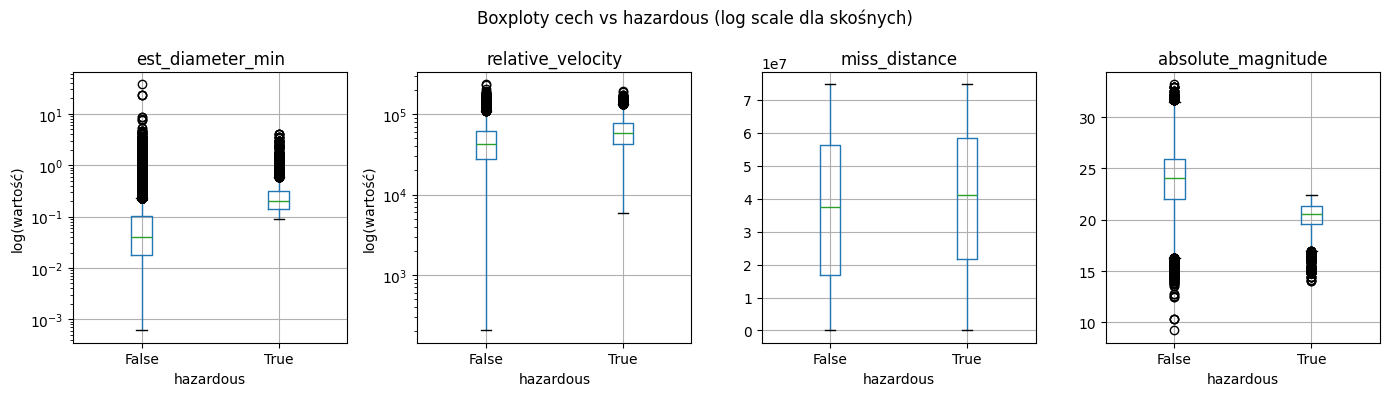

In [50]:
print('Outliery metodą IQR (granica = Q1/Q3 ± 1.5×IQR):')
for col in features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (df_clean[col] < Q1 - 1.5*IQR) | (df_clean[col] > Q3 + 1.5*IQR)
    n = mask.sum()
    print(f'  {col}: {n:5d} ({100*n/len(df_clean):.1f}%)')

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for i, col in enumerate(features):
    df_clean.boxplot(column=col, by='hazardous', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('hazardous')
    if col in ['est_diameter_min', 'relative_velocity']:
        axes[i].set_yscale('log')
        axes[i].set_ylabel('log(wartość)')

plt.suptitle('Boxploty cech vs hazardous (log scale dla skośnych)')
plt.tight_layout()
plt.show()

**Wnioski:**  
- `est_diameter_min`: 9.1% outlierów — to realne duże asteroidy, nie błędy pomiarowe  
- `relative_velocity`: 1.7% outlierów — szybkie obiekty, też realne  
- `miss_distance` i `absolute_magnitude`: poniżej 0.1% — marginalnie  
- Jak dla mnie to zostawiamy outliery bo usunięcie dużych asteroid zaburzyłoby klasę `hazardous=True`, bo duże obiekty częściej tam trafiają
- Lepszy `RobustScaler` niż `StandardScaler`, bo opiera się na medianie i IQR, więc outliery nie zaburzą skalowania

## 7. Duplikaty

Ten sam obiekt kosmiczny może pojawić się wielokrotnie w zbiorze. Każdy wiersz to osobny przelot obok Ziemi w innym momencie. Dlatego `relative_velocity` i `miss_distance` różnią się między wierszami tego samego obiektu.

In [51]:
print('Identyczne wiersze (wszystkie kolumny):', df.duplicated().sum())
print('Unikalne obiekty (id):', df['id'].nunique())
print('Łączna liczba wierszy:', len(df))
print(f'→ Jeden obiekt pojawia się średnio {len(df)/df["id"].nunique():.1f}x (różne przeloty)')

Identyczne wiersze (wszystkie kolumny): 0
Unikalne obiekty (id): 27423
Łączna liczba wierszy: 90836
→ Jeden obiekt pojawia się średnio 3.3x (różne przeloty)


**Wnioski:**  
- Identycznych wierszy jest 0, wiec nie ma co usuwać  
- 27 423 unikalne obiekty, 90 836 obserwacji — średnio jakoś 3.3 przeloty na obiekt  
- Każda obserwacja jest osobnym zdarzeniem z innymi wartościami `relative_velocity` i `miss_distance` potraktowałbym niezależnie

## 8. Stratified train/test split + zapis plików

Stratyfikacja konieczna, raczej nie musze tłumaczyć dlaczego.

In [52]:
X = df_clean.drop(columns=['hazardous'])
y = df_clean['hazardous'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f'Train: {X_train.shape[0]} wierszy | Test: {X_test.shape[0]} wierszy')
print(f'Proporcja hazardous w train: {y_train.mean():.3f}')
print(f'Proporcja hazardous w test:  {y_test.mean():.3f}')

Train: 72668 wierszy | Test: 18168 wierszy
Proporcja hazardous w train: 0.097
Proporcja hazardous w test:  0.097


## Faza 2b — Preprocessing

In [53]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

def get_shared_preprocessing_pipeline():
    """
    Gotowy Pipeline przetwarzania wstępnego dla całego zespołu.
    Zgodnie z decyzjami z Fazy 1a:
    - Brak braków danych (pomijamy SimpleImputer)
    - Zredukowane cechy (pomijamy SelectKBest)
    - Obecność outlierów wymusza zastosowanie RobustScaler.
    """
    pipeline = Pipeline([
        ('scaler', RobustScaler())
    ])

    return pipeline


print(f"Dane wczytane. Rozmiar X_train: {X_train.shape}")
print(f"Rozkład klas w y_train:\n{y_train.value_counts(normalize=True)}")

Dane wczytane. Rozmiar X_train: (72668, 4)
Rozkład klas w y_train:
hazardous
0    0.902681
1    0.097319
Name: proportion, dtype: float64


##Faza 3a - Naive Bayes

In [54]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (recall_score, precision_score, roc_auc_score,
                             balanced_accuracy_score, classification_report,
                             confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt
import numpy as np

In [55]:
pipeline = get_shared_preprocessing_pipeline()
pipeline.steps.append(('model', GaussianNB(priors=[0.5, 0.5])))
pipeline.fit(X_train, y_train)
y_proba = pipeline.predict_proba(X_test)[:, 1]

best_threshold = None
best_precision = 0

for thresh in np.arange(0.001, 0.999, 0.001):
    y_pred_t = (y_proba >= thresh).astype(int)
    rec = recall_score(y_test, y_pred_t, pos_label=1)
    prec = precision_score(y_test, y_pred_t, pos_label=1, zero_division=0)
    if rec == 1.0 and prec > best_precision:
        best_precision = prec
        best_threshold = thresh

print(f"Najlepszy próg:  {best_threshold:.3f}")
print(f"Precision:       {best_precision:.4f}")
print(f"Recall:          1.0000")

y_pred = (y_proba >= best_threshold).astype(int)

roc_auc = roc_auc_score(y_test, y_proba)
balanced_acc = balanced_accuracy_score(y_test, y_pred)
print(f"\nROC-AUC:           {roc_auc:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")
print(classification_report(y_test, y_pred))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Najlepszy próg:  0.007
Precision:       0.1600
Recall:          1.0000

ROC-AUC:           0.8700
Balanced Accuracy: 0.7169
              precision    recall  f1-score   support

           0       1.00      0.43      0.61     16400
           1       0.16      1.00      0.28      1768

    accuracy                           0.49     18168
   macro avg       0.58      0.72      0.44     18168
weighted avg       0.92      0.49      0.57     18168

Confusion matrix:
[[7115 9285]
 [   0 1768]]


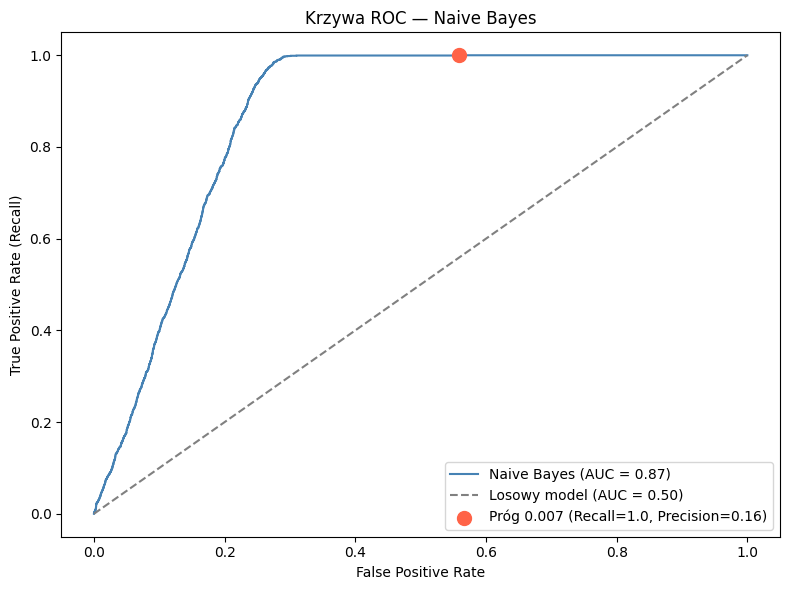

In [56]:

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc_curve = auc(fpr, tpr)
idx = np.argmin(np.abs(thresholds - best_threshold))

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='steelblue', label=f'Naive Bayes (AUC = {roc_auc_curve:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Losowy model (AUC = 0.50)')
plt.scatter([fpr[idx]], [tpr[idx]], color='tomato', zorder=5, s=100,
            label=f'Próg {best_threshold:.3f} (Recall=1.0, Precision={best_precision:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Krzywa ROC — Naive Bayes')
plt.legend()
plt.tight_layout()
plt.show()

# --- Ocena modelu ---
# GaussianNB osiąga AUC=0.87 czyli spoko rankinguje obiekty,
# ale ograniczony przez założenie rozkładu normalnego cech
# które w tym zbiorze jest niespełnione (silna skośność, outliery)
# przy progu 0.5(czyli model bierze za "hazardous" jeżeli prawdopodobieństwo jest >= 50%)
# Recall wynosi tylko śmieszne 0.27
# Dopiero obniżenie progu do 0.007 pozwala osiągnąć Recall=1.0(bo skoro ma być katastrofa to niechcemy żadnego)
# ale kosztem fałszywych alarmów (Precision ~0.16).
# W kontekście zadania (FN=katastrofa, FP=koszt) jest to wydaje mi sie jedyne ustawienie,
# jednak wysoki FPR (~0.56) oznacza że model bedzie bardzo kosztowny
# Naive Bayes nie jest odpowiednim modelem dla tego problemu.